# Phase 7 (Stage B) — Cross-modal alignment: video/text projection adapters

Trains two small adapters (`VideoAdapter`: 512-d → D, `TextAdapter`: 768-d → D) with a label-anchored symmetric contrastive loss on top of the two **already-frozen** Stage A encoders (FusionClassifier's penultimate video embedding, `text_mood_clf`'s penultimate text embedding). See `project/docs/cross_modal_alignment_plan.pdf` for the full architecture/feasibility writeup.

**Scope note:** no text training corpus is available (only the trained `text_mood_clf` model exists on disk, not its data) — by explicit choice, the text side uses only the 5 class-name strings as fixed anchors, not synthetic sentences. This is documented throughout rather than papered over; see the plan PDF's "core feasibility question" section for what this does and doesn't buy you.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parents[1]  # notebooks/ -> project/ -> repo root
sys.path.insert(0, str(REPO_ROOT))

from project.config import load_config, resolve_path

cfg = load_config()


## Step 1 — cache the 512-d video embedding

Runs the frozen `FusionClassifier` backbone (trained in Phase 5) over the already-cached 1280-d VideoMAE+CLIP features to produce the penultimate, task-supervised 512-d representation Stage B projects from. Idempotent — skips clips already cached.

In [2]:
from project.features.extract_video_embedding_512 import extract_video_embeddings

extract_video_embeddings(cfg)

[train] 0/2232 clips pending 512-d embedding extraction
[val] 0/479 clips pending 512-d embedding extraction
[test] 0/478 clips pending 512-d embedding extraction
512-d video embeddings -> /Users/rafiabhista/Documents/code/apple/c1_audio/emomv_2/project/features/video_embedding_512


## Step 2 — train the adapters

In [3]:
import torch
from torch.utils.data import DataLoader

from project.datasets.feature_dataset import CachedEmbeddingDataset
from project.models.adapters import AlignmentModel
from project.models.encoders import get_device
from project.training.alignment_common import load_text_anchors
from project.training.losses import label_anchored_contrastive_loss
from project.training.utils import EarlyStopping, save_checkpoint, set_seed
from project.training.train_alignment import evaluate_v2t_accuracy

a_cfg = cfg['alignment']
set_seed(cfg['seed'])
device = get_device(cfg['encoders']['device_preference'])
print('device:', device)

video_dir = resolve_path(cfg, 'paths.video_embedding_512_dir')
train_ds = CachedEmbeddingDataset(resolve_path(cfg, 'paths.train_csv'), [(video_dir, 'video_id')])
val_ds = CachedEmbeddingDataset(resolve_path(cfg, 'paths.val_csv'), [(video_dir, 'video_id')])
print('train:', len(train_ds), ' val:', len(val_ds))

text_z_raw, id2label = load_text_anchors(cfg, device)
print('text anchors (fixed, 5 class-name strings):', id2label)

device: mps
train: 2232  val: 479


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

text anchors (fixed, 5 class-name strings): {0: 'excited', 1: 'fear', 2: 'tense', 3: 'sad', 4: 'relax'}


In [4]:
model = AlignmentModel(shared_dim=a_cfg['shared_dim'], dropout=a_cfg['adapter_dropout'],
                        logit_scale_init=a_cfg['logit_scale_init'], logit_scale_max=a_cfg['logit_scale_max']).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=a_cfg['lr'], weight_decay=a_cfg['weight_decay'])
train_loader = DataLoader(train_ds, batch_size=a_cfg['batch_size'], shuffle=True)
val_loader = DataLoader(val_ds, batch_size=a_cfg['batch_size'], shuffle=False)

early_stopping = EarlyStopping(patience=a_cfg['early_stopping_patience'], mode='max')
checkpoint_path = resolve_path(cfg, 'paths.checkpoints_dir') / 'alignment_adapters_best.pt'

for epoch in range(1, a_cfg['max_epochs'] + 1):
    model.train()
    running_loss, n_batches = 0.0, 0
    for x, y, _video_ids in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        video_z = model.encode_video(x)
        text_z = model.encode_text(text_z_raw.to(device))
        loss, parts = label_anchored_contrastive_loss(video_z, text_z, y, model.logit_scale())
        loss.backward()
        optimizer.step()
        running_loss += parts['total']
        n_batches += 1
    train_loss = running_loss / max(n_batches, 1)
    val_acc = evaluate_v2t_accuracy(model, text_z_raw, val_loader, device)
    print(f"epoch {epoch:03d}  train_loss={train_loss:.4f}  val_v2t_acc={val_acc:.4f}")
    if early_stopping.step(val_acc):
        save_checkpoint(model, optimizer, epoch, {'val_v2t_accuracy': val_acc}, checkpoint_path)
    if early_stopping.should_stop:
        print(f"early stopping at epoch {epoch} (best val_v2t_acc={early_stopping.best_score:.4f})")
        break

epoch 001  train_loss=2.5084  val_v2t_acc=0.8038
epoch 002  train_loss=2.0003  val_v2t_acc=0.8038
epoch 003  train_loss=1.9703  val_v2t_acc=0.7912
epoch 004  train_loss=1.9825  val_v2t_acc=0.8142
epoch 005  train_loss=1.9410  val_v2t_acc=0.8100
epoch 006  train_loss=1.9266  val_v2t_acc=0.7996
epoch 007  train_loss=1.9082  val_v2t_acc=0.8038
epoch 008  train_loss=1.9156  val_v2t_acc=0.8058
epoch 009  train_loss=1.9193  val_v2t_acc=0.8079
epoch 010  train_loss=1.9027  val_v2t_acc=0.8205
epoch 011  train_loss=1.8921  val_v2t_acc=0.8017
epoch 012  train_loss=1.8956  val_v2t_acc=0.7975
epoch 013  train_loss=1.9155  val_v2t_acc=0.7891
epoch 014  train_loss=1.8893  val_v2t_acc=0.8038
epoch 015  train_loss=1.8969  val_v2t_acc=0.7954
epoch 016  train_loss=1.8908  val_v2t_acc=0.8058
epoch 017  train_loss=1.8748  val_v2t_acc=0.8017
epoch 018  train_loss=1.8759  val_v2t_acc=0.8100
epoch 019  train_loss=1.8571  val_v2t_acc=0.8017
epoch 020  train_loss=1.8733  val_v2t_acc=0.7808
epoch 021  train_los

## Step 3 — evaluate on the held-out test split

Reports video→text Recall@1 (overall + per-DS1/DS2/DS3), the per-class breakdown, and the modality-gap diagnostic (mean cosine similarity between each class's video centroid and its text anchor — lower than 1.0 is expected and normal for CLIP-family models, but worth tracking explicitly rather than assuming it's zero).

In [5]:
from project.evaluation.evaluate_alignment import (
    embed_split, compute_metrics, plot_tsne,
)
from project.training.utils import load_checkpoint
import pandas as pd, numpy as np, json

load_checkpoint(model, checkpoint_path, map_location=device)
model.eval()
with torch.no_grad():
    text_z = model.encode_text(text_z_raw.to(device)).cpu()

test_csv = resolve_path(cfg, 'paths.test_csv')
video_z, labels, video_ids = embed_split(model, video_dir, test_csv, device)

results = {'overall': compute_metrics(video_z, labels, text_z, id2label)}
print('OVERALL:', results['overall'])

test_meta = pd.read_csv(test_csv).set_index('video_id')['dataset_source']
ds_labels = np.array([test_meta[vid] for vid in video_ids])
for ds in sorted(set(ds_labels.tolist())):
    mask = ds_labels == ds
    results[ds] = compute_metrics(video_z[mask], labels[mask], text_z, id2label)
    print(ds, results[ds]['v2t_accuracy'])

results_dir = resolve_path(cfg, 'paths.results_dir')
with open(results_dir / 'alignment_metrics.json', 'w') as fh:
    json.dump(results, fh, indent=2)

OVERALL: {'n_samples': 478, 'v2t_accuracy': 0.8096234309623431, 'per_class_recall': {'excited': 0.8076923076923077, 'fear': 0.8765432098765432, 'tense': 0.7058823529411765, 'sad': 0.797752808988764, 'relax': 0.8308823529411765}, 'modality_gap_cosine_sim': {'excited': 0.7090656757354736, 'fear': 0.7275174260139465, 'tense': 0.6938539743423462, 'sad': 0.6964554786682129, 'relax': 0.7224149107933044}}
DS1 0.8865979381443299
DS2 0.5084745762711864
DS3 0.41935483870967744


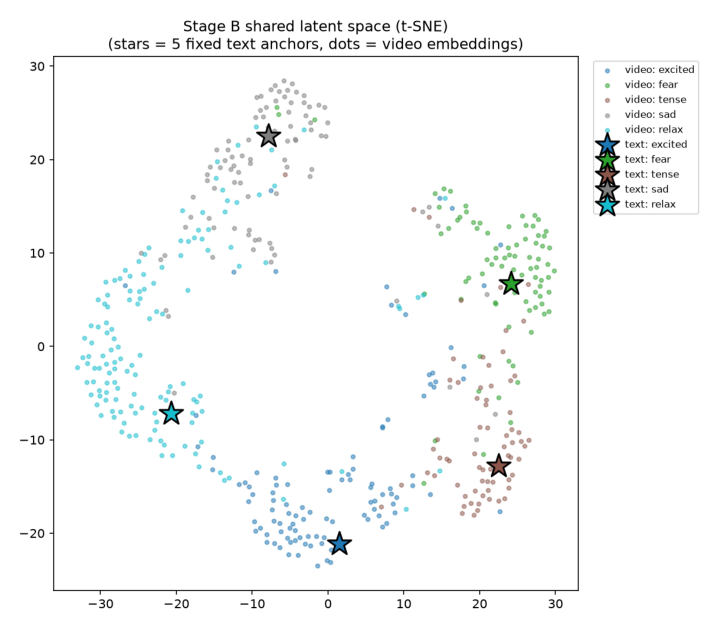

In [6]:
plot_tsne(video_z, labels, text_z, id2label, results_dir / 'alignment_tsne.png')

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread(results_dir / 'alignment_tsne.png')
plt.figure(figsize=(9, 8)); plt.imshow(img); plt.axis('off'); plt.show()

## Next: Stage C

With the shared latent space trained and evaluated, the next stage (per the plan PDF) is the MusicGen bridge adapter — Milestone 1 (embedding-translation only, MusicGen fully frozen) using the EmoMV `MATCH` clips' own audio tracks as mood-paired training targets.